### K Nearest Neighbour Classification Algorithm 

### Write a python programm to implement KNN algorithm to predict breast Cancer using breast cancer wisconsin dataset.

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns

In [2]:
sns.set()

In [3]:
breast_cancer_data = load_breast_cancer()
X_df = pd.DataFrame(breast_cancer_data.data,columns=breast_cancer_data.feature_names)
X_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:
X_df=X_df[['mean area','mean compactness']]     ### Method for redefining the DataFrame
X_df.head()

,mean area,mean compactness
0,1001.0,0.27760
1,1326.0,0.07864
2,1203.0,0.15990
3,386.1,0.28390
4,1297.0,0.13280


In [6]:
X_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean area         569 non-null    float64
 1   mean compactness  569 non-null    float64
dtypes: float64(2)
memory usage: 9.0 KB


In [7]:
Y_df = pd.Categorical.from_codes(breast_cancer_data.target,breast_cancer_data.target_names)
print(Y_df)

['malignant', 'malignant', 'malignant', 'malignant', 'malignant', ..., 'malignant', 'malignant', 'malignant', 'malignant', 'benign']
Length: 569
Categories (2, object): ['malignant', 'benign']


In [8]:
Y_df = pd.get_dummies(Y_df,drop_first = True)

In [9]:
Y_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   benign  569 non-null    bool 
dtypes: bool(1)
memory usage: 701.0 bytes


In [10]:
print(Y_df)

     benign
0     False
1     False
2     False
3     False
4     False
..      ...
564   False
565   False
566   False
567   False
568    True

[569 rows x 1 columns]


In [11]:
X_train,X_test,Y_train,Y_test = train_test_split(X_df,Y_df,random_state=1,test_size=0.25,shuffle=True)

In [12]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 421 to 415
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean area         143 non-null    float64
 1   mean compactness  143 non-null    float64
dtypes: float64(2)
memory usage: 3.4 KB


In [13]:
Y_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 421 to 415
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   benign  143 non-null    bool 
dtypes: bool(1)
memory usage: 1.3 KB


In [14]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 562 to 37
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean area         426 non-null    float64
 1   mean compactness  426 non-null    float64
dtypes: float64(2)
memory usage: 10.0 KB


In [15]:
Y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 562 to 37
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   benign  426 non-null    bool 
dtypes: bool(1)
memory usage: 3.7 KB


In [16]:
# KNN model
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, Y_train)

C:\Users\Abdul Shaikh\Documents\Anaconda\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


<Axes: xlabel='mean area', ylabel='mean compactness'>

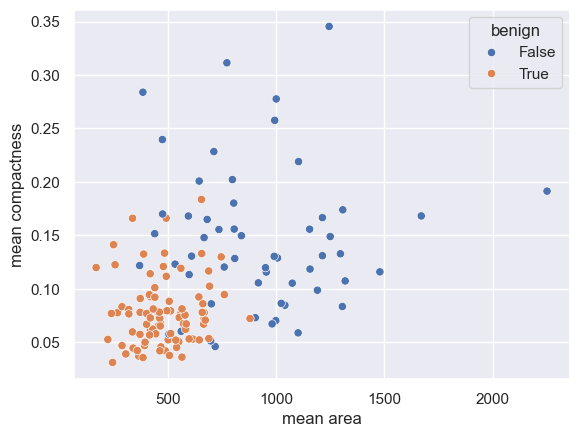

In [17]:

combined_df=pd.concat([X_test,Y_test],axis=1)
sns.scatterplot(x="mean area",y="mean compactness",hue="benign",data=combined_df)

In [18]:
Y_pred=knn.predict(X_test)

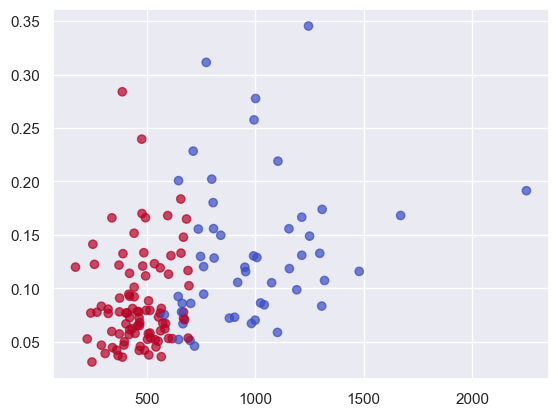

In [19]:

plt.scatter(X_test["mean area"],X_test["mean compactness"],c=Y_pred,cmap="coolwarm",alpha=0.7)

In [20]:
cf=confusion_matrix(Y_test,Y_pred)
print(cf)

[[42 13]
 [ 9 79]]


In [21]:
tp,fn,fp,tn=confusion_matrix(Y_test,Y_pred,labels=[1,0]).reshape(-1)

In [22]:
print(tp,fn,fp,tn)

79 9 13 42


In [23]:
labels=["True Negatives","False Positive","False Negative","True Positive"]
labels=np.asarray(labels).reshape(2,2)

<bound method _AxesBase.set_xlabel of <Axes: >>

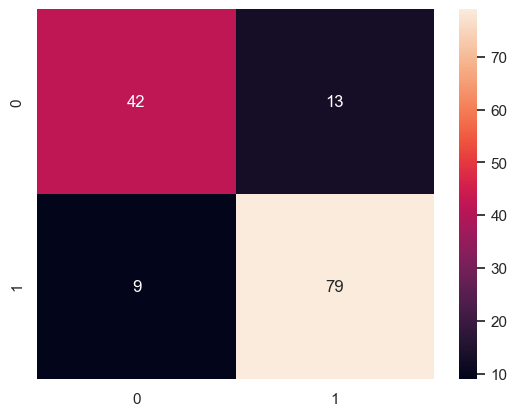

In [24]:

categories=["Zero","One"]
ax=plt.subplot()
sns.heatmap(cf,annot=True,ax=ax)
ax.set_xlabel

[Text(0, 0.5, 'Malignant'), Text(0, 1.5, 'Benign')]

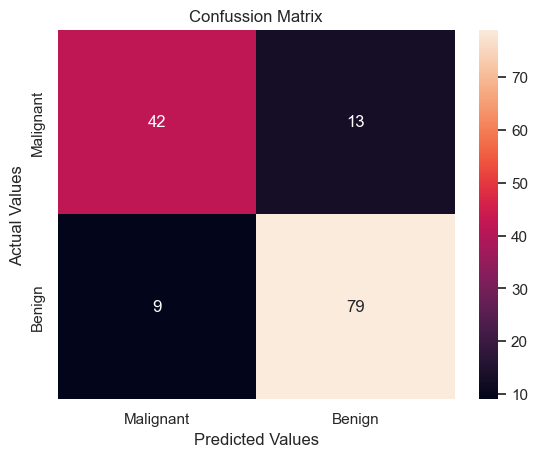

In [25]:

categories=["Zero","One"]
ax=plt.subplot()
sns.heatmap(cf,annot=True,ax=ax)
ax.set_xlabel("Predicted Values")
ax.set_ylabel("Actual Values")
ax.set_title("Confussion Matrix")
ax.xaxis.set_ticklabels(["Malignant","Benign"])
ax.yaxis.set_ticklabels(["Malignant","Benign"])

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(Y_test, Y_pred)
precision = precision_score(Y_test, Y_pred)
recall = recall_score(Y_test, Y_pred)
f1 = f1_score(Y_test, Y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8461538461538461
Precision: 0.8586956521739131
Recall: 0.8977272727272727
F1-score: 0.8777777777777778
